<a href="https://colab.research.google.com/github/Dewisrirahayu05/TugasAkhir/blob/main/Pengelompokan_Profil_Kemiskinan_Provinsi_di_Indonesia_Menggunakan_Metode_K_Means_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pengelompokan Profil Kemiskinan Provinsi di Indonesia Menggunakan Metode K-Means**

### **Tujuan Penelitian**
Menerapkan algoritma K-Means clustering untuk mengelompokkan 38 provinsi di Indonesia berdasarkan enam variabel kemiskinan (**IPM, P0, P1, P2, GK, dan Gini Ratio**), sehingga menghasilkan suatu sistem berbasis dashboard interaktif yang dapat memberikan rekomendasi jenis bantuan yang berbeda sesuai karakteristik masing-masing kelompok (cluster), guna mendukung penyaluran bantuan/dana yang lebih tepat sasaran.


# **Memanggil Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

folder_path = '/content/drive/MyDrive/Tugas Akhir Dewi 2022-2026/dataset/'

#**Data Collection (Pengumpulan Data)**

In [ ]:
# Membaca semua file CSV (ganti nama file sesuai punyamu)
try:
  IPM = pd.read_csv(folder_path + 'Indeks Pembangunan Manusia Menurut Provinsi, 2025.csv')
  P0 = pd.read_csv(folder_path + 'Persentase Penduduk Miskin (P0) Menurut Provinsi dan Daerah, 2025.csv')
  P1 = pd.read_csv(folder_path + 'Indeks Kedalaman Kemiskinan (P1) Menurut Provinsi dan Daerah, 2025.csv')
  P2 = pd.read_csv(folder_path + 'Indeks Keparahan Kemiskinan (P2) Menurut Provinsi dan Daerah, 2025.csv')
  GKM = pd.read_csv(folder_path + 'Garis Kemiskinan Makanan (Rupiah_Kapita_Bulan) Menurut Provinsi dan Daerah, 2025.csv')
  GKNM = pd.read_csv(folder_path + 'Garis Kemiskinan Non-Makanan (Rupiah_Kapita_Bulan) Menurut Provinsi dan Daerah, 2025.csv')
  GR = pd.read_csv(folder_path + 'Gini Ratio Menurut Provinsi dan Daerah, 2025.csv')
  print("✅ Data berhasil diimport!")

except FileNotFoundError as e:
  print(f"❌ Gagal memuat file: {e}. Periksa kembali nama file di folder dataset.")

✅ Data berhasil diimport!


# **Pre-Processing Data**

##**Data Cleaning (Pembersihan Data)**

###**Indeks Pembangunan Manusia Menurut Provinsi 2025**

In [ ]:
IPM = pd.read_csv(folder_path + 'Indeks Pembangunan Manusia Menurut Provinsi, 2025.csv')
print(IPM.shape)
print(IPM)

(39, 2)
                     Provinsi  Indeks Pembangunan Manusia
0                        Aceh                       76.23
1              Sumatera Utara                       76.47
2              Sumatera Barat                       77.27
3                        Riau                       76.31
4                       Jambi                       75.13
5            Sumatera Selatan                       74.76
6                    Bengkulu                       75.68
7                     Lampung                       73.98
8   Kepulauan Bangka Belitung                       75.26
9              Kepulauan Riau                       80.53
10                DKI Jakarta                       85.05
11                 Jawa Barat                       75.90
12                Jawa Tengah                       74.77
13              DI Yogyakarta                       82.48
14                 Jawa Timur                       76.13
15                     Banten                       77.25
16    

In [ ]:
# Melihat informasi dataset yang sudah dibersihkan
IPM.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Provinsi                    39 non-null     object 
 1   Indeks Pembangunan Manusia  39 non-null     float64
dtypes: float64(1), object(1)
memory usage: 756.0+ bytes


In [ ]:
# Menampilkan ringkasan statistik deskriptif data IPM
IPM.describe()

,Indeks Pembangunan Manusia
count,39.000000
mean,74.290256
std,5.133943
min,54.910000
25%,72.720000
50%,74.860000
75%,76.270000
max,85.050000


In [ ]:
# Ubah nama kolom
IPM.columns = ['38 Provinsi', 'IPM']
print(IPM.shape)
IPM.head()

(39, 2)


,38 Provinsi,IPM
0,Aceh,76.23
1,Sumatera Utara,76.47
2,Sumatera Barat,77.27
3,Riau,76.31
4,Jambi,75.13


In [ ]:
# Menghapus baris Indonesia
IPM = IPM[IPM['38 Provinsi'] != 'Indonesia']
IPM.reset_index(drop=True, inplace=True)

print(IPM.shape)
IPM.tail()

(38, 2)


,38 Provinsi,IPM
33,Papua Barat Daya,70.55
34,Papua,74.69
35,Papua Selatan,69.54
36,Papua Tengah,60.64
37,Papua Pegunungan,54.91


In [ ]:
# Menampilkan ringkasan statistik deskriptif data IPM setelah baris Indonesia  dihapus
IPM.describe()

,IPM
count,38.000000
mean,74.247895
std,5.195945
min,54.910000
25%,72.670000
50%,74.815000
75%,76.290000
max,85.050000


###**Persentase Penduduk Miskin (P0) Menurut Provinsi 2025**

In [ ]:
P0 = pd.read_csv(folder_path + 'Persentase Penduduk Miskin (P0) Menurut Provinsi dan Daerah, 2025.csv')
print(P0.shape)
P0.head()

(43, 10)


,38 Provinsi,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,Persentase Penduduk Miskin (P0) Menurut Provin...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Perkotaan,NaN,NaN,Perdesaan,NaN,NaN,Jumlah,NaN,NaN
2,NaN,2025,NaN,NaN,2025,NaN,NaN,2025,NaN,NaN
3,NaN,Semester 1 (Maret),Semester 2 (September),Tahunan,Semester 1 (Maret),Semester 2 (September),Tahunan,Semester 1 (Maret),Semester 2 (September),Tahunan
4,ACEH,8.54,8.15,-,14.44,14.51,-,12.33,12.22,-


In [ ]:
# Ambil data mulai baris ke-4
P0 = P0.iloc[4:].copy()

# Pilih kolom yang dibutuhkan
P0 = P0[['38 Provinsi', 'Unnamed: 8']]

# Ubah nama kolom
P0.columns = ['38 Provinsi', 'P0']

# Reset index
P0.reset_index(drop=True, inplace=True)

# Tampilkan hasil
P0.head()

,38 Provinsi,P0
0,ACEH,12.22
1,SUMATERA UTARA,7.24
2,SUMATERA BARAT,5.31
3,RIAU,6.3
4,JAMBI,6.89


In [ ]:
# Cek jumlah baris setelah cleaning
print(P0.shape)

# Lihat baris terakhir
P0.tail()

(39, 2)


,38 Provinsi,P0
34,PAPUA,17.82
35,PAPUA SELATAN,19.26
36,PAPUA TENGAH,29.45
37,PAPUA PEGUNUNGAN,27.21
38,INDONESIA,8.25


In [ ]:
# Menghapus baris Indonesia
P0 = P0[P0['38 Provinsi'] != 'INDONESIA']
P0.reset_index(drop=True, inplace=True)

print(P0.shape)
P0.tail()

(38, 2)


,38 Provinsi,P0
33,PAPUA BARAT DAYA,17.5
34,PAPUA,17.82
35,PAPUA SELATAN,19.26
36,PAPUA TENGAH,29.45
37,PAPUA PEGUNUNGAN,27.21


In [ ]:
# Melihat informasi dataset yang sudah dibersihkan
P0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   38 Provinsi  38 non-null     object
 1   P0           38 non-null     object
dtypes: object(2)
memory usage: 740.0+ bytes


In [ ]:
# mengubah tipe data kolom P0 dari object ke numerik
P0['P0'] = pd.to_numeric(P0['P0'], errors='coerce')
P0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   38 Provinsi  38 non-null     object 
 1   P0           38 non-null     float64
dtypes: float64(1), object(1)
memory usage: 740.0+ bytes


In [ ]:
P0.describe()

,P0
count,38.000000
mean,10.269474
std,6.268886
min,3.420000
25%,5.530000
50%,9.345000
75%,12.135000
max,29.450000


###**Indeks Kedalaman Kemiskinan (P1) Menurut Provinsi 2025**

In [ ]:
P1 = pd.read_csv(folder_path + 'Indeks Kedalaman Kemiskinan (P1) Menurut Provinsi dan Daerah, 2025.csv')
print(P1.shape)
P1.head()

(43, 10)


,38 Provinsi,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,Indeks Kedalaman Kemiskinan (P1) Menurut Provi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Perkotaan,NaN,NaN,Perdesaan,NaN,NaN,Perkotaan+Perdesaan,NaN,NaN
2,NaN,2025,NaN,NaN,2025,NaN,NaN,2025,NaN,NaN
3,NaN,Semester 1 (Maret),Semester 2 (September),Tahunan,Semester 1 (Maret),Semester 2 (September),Tahunan,Semester 1 (Maret),Semester 2 (September),Tahunan
4,ACEH,1.19,1.22,-,2.2,2.53,-,1.84,2.06,-


In [ ]:
# Ambil data mulai baris ke-4
P1 = P1.iloc[4:].copy()

# Pilih kolom yang dibutuhkan
P1 = P1[['38 Provinsi', 'Unnamed: 8']]

# Ubah nama kolom
P1.columns = ['38 Provinsi', 'P1']

# Reset index
P1.reset_index(drop=True, inplace=True)

# Tampilkan hasil
P1.head()

,38 Provinsi,P1
0,ACEH,2.06
1,SUMATERA UTARA,0.9
2,SUMATERA BARAT,0.86
3,RIAU,0.79
4,JAMBI,0.83


In [ ]:
# Cek jumlah baris setelah cleaning
print(P1.shape)

# Lihat baris terakhir
P1.tail()

(39, 2)


,38 Provinsi,P1
34,PAPUA,3.61
35,PAPUA SELATAN,4.07
36,PAPUA TENGAH,7.94
37,PAPUA PEGUNUNGAN,5.99
38,INDONESIA,1.29


In [ ]:
# Menghapus baris Indonesia
P1 = P1[P1['38 Provinsi'] != 'INDONESIA']
P1.reset_index(drop=True, inplace=True)

print(P1.shape)
P1.tail()

(38, 2)


,38 Provinsi,P1
33,PAPUA BARAT DAYA,3.21
34,PAPUA,3.61
35,PAPUA SELATAN,4.07
36,PAPUA TENGAH,7.94
37,PAPUA PEGUNUNGAN,5.99


In [ ]:
# Melihat informasi dataset yang sudah dibersihkan
P1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   38 Provinsi  38 non-null     object
 1   P1           38 non-null     object
dtypes: object(2)
memory usage: 740.0+ bytes


In [ ]:
# Mengubah tipe data kolom P1 dari object ke numerik
P1['P1']= pd.to_numeric(P1['P1'], errors='coerce')
P1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   38 Provinsi  38 non-null     object 
 1   P1           38 non-null     float64
dtypes: float64(1), object(1)
memory usage: 740.0+ bytes


In [ ]:
P1.describe()

,P1
count,38.000000
mean,1.780526
std,1.565703
min,0.380000
25%,0.800000
50%,1.295000
75%,2.037500
max,7.940000


###**Indeks Keparahan Kemiskinan (P2) Menurut Provinsi 2025**

In [ ]:
P2 = pd.read_csv(folder_path + 'Indeks Keparahan Kemiskinan (P2) Menurut Provinsi dan Daerah, 2025.csv')
print(P2.shape)
P2.head()

(43, 10)


,38 Provinsi,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,Indeks Keparahan Kemiskinan (P2) Menurut Provi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Perkotaan,NaN,NaN,Perdesaan,NaN,NaN,Perkotaan+Perdesaan,NaN,NaN
2,NaN,2025,NaN,NaN,2025,NaN,NaN,2025,NaN,NaN
3,NaN,Semester 1 (Maret),Semester 2 (September),Tahunan,Semester 1 (Maret),Semester 2 (September),Tahunan,Semester 1 (Maret),Semester 2 (September),Tahunan
4,ACEH,0.26,0.24,-,0.51,0.68,-,0.42,0.52,-


In [ ]:
# Ambil data mulai baris ke-4
P2 = P2.iloc[4:].copy()

# Pilih kolom yang dibutuhkan
P2 = P2[['38 Provinsi', 'Unnamed: 8']]

# Ubah nama Kolom
P2.columns = ['38 Provinsi', 'P2']

# Reset index
P2.reset_index(drop=True, inplace=True)

# Tampilkan hasil
P2.head()

,38 Provinsi,P2
0,ACEH,0.52
1,SUMATERA UTARA,0.19
2,SUMATERA BARAT,0.22
3,RIAU,0.15
4,JAMBI,0.15


In [ ]:
# Cek jumlah baris setelah cleaning
print(P2.shape)

# Lihat baris terakhir
P2.tail()

(39, 2)


,38 Provinsi,P2
34,PAPUA,1.01
35,PAPUA SELATAN,1.12
36,PAPUA TENGAH,2.89
37,PAPUA PEGUNUNGAN,1.71
38,INDONESIA,0.3


In [ ]:
# Menghapus baris INDONESIA
P2 = P2[P2['38 Provinsi'] != 'INDONESIA']
P2.reset_index(drop=True, inplace=True)

print(P2.shape)
P2.tail()

(38, 2)


,38 Provinsi,P2
33,PAPUA BARAT DAYA,0.91
34,PAPUA,1.01
35,PAPUA SELATAN,1.12
36,PAPUA TENGAH,2.89
37,PAPUA PEGUNUNGAN,1.71


In [ ]:
# Melihat informasi dataset yang sudah dibersihkan
P2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   38 Provinsi  38 non-null     object
 1   P2           38 non-null     object
dtypes: object(2)
memory usage: 740.0+ bytes


In [ ]:
# mengubah tipe data kolom P2 dari object ke numerik
P2['P2'] = pd.to_numeric(P2['P2'], errors='coerce')
P2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   38 Provinsi  38 non-null     object 
 1   P2           38 non-null     float64
dtypes: float64(1), object(1)
memory usage: 740.0+ bytes


In [ ]:
P2.describe()

,P2
count,38.000000
mean,0.468158
std,0.532789
min,0.050000
25%,0.172500
50%,0.295000
75%,0.535000
max,2.890000


###**Garis Kemiskinan**
Dalam metodologi BPS, yang disebut sebagai Garis Kemiskinan (GK) adalah hasil penjumlahan dari Garis Kemiskinan Makanan (GKM) dan Garis Kemiskinan Non-Makanan(GKNM).Rumus Dasarnya:$$GK = GKM + GKNM$$

####**Garis Kemiskinan Makanan (Rupiah_Kapita_Bulan) Menurut Provinsi 2025**

In [ ]:
GKM = pd.read_csv(folder_path + 'Garis Kemiskinan Makanan (Rupiah_Kapita_Bulan) Menurut Provinsi dan Daerah, 2025.csv')
print(GKM.shape)
GKM.head()

(43, 10)


,38 Provinsi,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,Garis Kemiskinan Makanan (Rupiah/Kapita/Bulan)...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Perkotaan,NaN,NaN,Perdesaan,NaN,NaN,Perkotaan+Perdesaan,NaN,NaN
2,NaN,2025,NaN,NaN,2025,NaN,NaN,2025,NaN,NaN
3,NaN,Semester 1 (Maret),Semester 2 (September),Tahunan,Semester 1 (Maret),Semester 2 (September),Tahunan,Semester 1 (Maret),Semester 2 (September),Tahunan
4,ACEH,538448,569571,-,503661,536191,-,515075,547511,-


In [ ]:
# Ambil data mulai baris ke-4
GKM = GKM.iloc[4:].copy()

# Pilih kolom yang dibutuhkan
GKM = GKM[['38 Provinsi', 'Unnamed: 8']]

# Ubah nama kolom
GKM.columns = ['38 Provinsi', 'GKM']

# Reset index
GKM.reset_index(drop=True, inplace=True)

# Tampilkan hasil
GKM.head()

,38 Provinsi,GKM
0,ACEH,547511
1,SUMATERA UTARA,551093
2,SUMATERA BARAT,592911
3,RIAU,549211
4,JAMBI,542466


In [ ]:
# Cek jumlah baris setelah cleaning
print(GKM.shape)

# Lihat baris terakhir
GKM.tail()

(39, 2)


,38 Provinsi,GKM
34,PAPUA,502801
35,PAPUA SELATAN,450134
36,PAPUA TENGAH,662158
37,PAPUA PEGUNUNGAN,942805
38,INDONESIA,478955


In [ ]:
# Menghapus baris INDONESIA
GKM = GKM[GKM['38 Provinsi'] != 'INDONESIA']
GKM.reset_index(drop=True, inplace=True)

print(GKM.shape)
GKM.tail()

(38, 2)


,38 Provinsi,GKM
33,PAPUA BARAT DAYA,629595
34,PAPUA,502801
35,PAPUA SELATAN,450134
36,PAPUA TENGAH,662158
37,PAPUA PEGUNUNGAN,942805


In [ ]:
# Melihat informasi dataset yang sudah dibersihkan
GKM.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   38 Provinsi  38 non-null     object
 1   GKM          38 non-null     object
dtypes: object(2)
memory usage: 740.0+ bytes


In [ ]:
# Mengubah tipe data kolom GKM dari object ke numerik
GKM['GKM'] = pd.to_numeric(GKM['GKM'], errors='coerce')
GKM.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   38 Provinsi  38 non-null     object
 1   GKM          38 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 740.0+ bytes


In [ ]:
GKM.describe()

,GKM
count,38.000000
mean,528730.447368
std,112156.797157
min,386850.000000
25%,445751.750000
50%,513739.500000
75%,590739.500000
max,942805.000000


####**Garis Kemiskinan Non-Makanan (Rupiah_Kapita_Bulan) Menurut Provinsi 2025**

In [ ]:
GKNM = pd.read_csv(folder_path + 'Garis Kemiskinan Non-Makanan (Rupiah_Kapita_Bulan) Menurut Provinsi dan Daerah, 2025.csv')
print(GKNM.shape)
GKNM.head()

(43, 10)


,38 Provinsi,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,Garis Kemiskinan Non-Makanan (Rupiah/Kapita/Bu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Perkotaan,NaN,NaN,Perdesaan,NaN,NaN,Perkotaan+Perdesaan,NaN,NaN
2,NaN,2025,NaN,NaN,2025,NaN,NaN,2025,NaN,NaN
3,NaN,Semester 1 (Maret),Semester 2 (September),Tahunan,Semester 1 (Maret),Semester 2 (September),Tahunan,Semester 1 (Maret),Semester 2 (September),Tahunan
4,ACEH,178074,186630,-,151774,156894,-,161172,167592,-


In [ ]:
# Ambil data mulai baris ke-4
GKNM = GKNM.iloc[4:].copy()

# Pilih kolom yang dibutuhkan
GKNM = GKNM[['38 Provinsi', 'Unnamed: 8']]

# Ubah nama kolom
GKNM.columns = ['38 Provinsi', 'GKNM']

# Reset index
GKNM.reset_index(drop=True, inplace=True)

# Tampilkan hasil
GKNM.head()

,38 Provinsi,GKNM
0,ACEH,167592
1,SUMATERA UTARA,167127
2,SUMATERA BARAT,183606
3,RIAU,198134
4,JAMBI,171383


In [ ]:
# Cek jumlah baris setelah cleaning
print(GKNM.shape)

# Lihat baris terakhir
GKNM.tail()

(39, 2)


,38 Provinsi,GKNM
34,PAPUA,233919
35,PAPUA SELATAN,137130
36,PAPUA TENGAH,211685
37,PAPUA PEGUNUNGAN,292523
38,INDONESIA,162488


In [ ]:
# Menghapus baris Indonesia
GKNM = GKNM[GKNM['38 Provinsi'] != 'INDONESIA']
GKNM.reset_index(drop=True, inplace=True)

print(GKNM.shape)
GKNM.tail()

(38, 2)


,38 Provinsi,GKNM
33,PAPUA BARAT DAYA,226062
34,PAPUA,233919
35,PAPUA SELATAN,137130
36,PAPUA TENGAH,211685
37,PAPUA PEGUNUNGAN,292523


In [ ]:
# Melihat informasi dataset yang sudah dibersihkan
GKNM.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   38 Provinsi  38 non-null     object
 1   GKNM         38 non-null     object
dtypes: object(2)
memory usage: 740.0+ bytes


In [ ]:
# mengubah tipe data kolom GKNM dari object ke numerik
GKNM['GKNM'] = pd.to_numeric(GKNM['GKNM'], errors='coerce')
GKNM.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   38 Provinsi  38 non-null     object
 1   GKNM         38 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 740.0+ bytes


In [ ]:
GKNM.describe()

,GKNM
count,38.000000
mean,183133.052632
std,48920.823779
min,110954.000000
25%,140716.500000
50%,169580.500000
75%,212547.500000
max,292523.000000


####**Hitung GK Dengan Menggabungkan Berdasarkan Provinsi**

In [ ]:
# Gabungkan berdasarkan provinsi
GK = pd.merge(GKM, GKNM, on='38 Provinsi')

# Hitung GK
GK['GK'] = GK['GKM'] + GK['GKNM']

# Tampilkan hasil
print(GK.shape)
GK.head()

(38, 4)


,38 Provinsi,GKM,GKNM,GK
0,ACEH,547511,167592,715103
1,SUMATERA UTARA,551093,167127,718220
2,SUMATERA BARAT,592911,183606,776517
3,RIAU,549211,198134,747345
4,JAMBI,542466,171383,713849


In [ ]:
# Ambil data mulai baris ke-1
GK = GK.iloc[0:].copy()

# Pilih kolom yang dibutuhkan
GK = GK[['38 Provinsi', 'GK']]

# Reset index
GK.reset_index(drop=True, inplace=True)

# Tampilkan hasil
print(GK.shape)
print(GK)

(38, 2)
             38 Provinsi       GK
0                   ACEH   715103
1         SUMATERA UTARA   718220
2         SUMATERA BARAT   776517
3                   RIAU   747345
4                  JAMBI   713849
5       SUMATERA SELATAN   609044
6               BENGKULU   712003
7                LAMPUNG   634062
8   KEP. BANGKA BELITUNG   992426
9              KEP. RIAU   870738
10           DKI JAKARTA   897768
11            JAWA BARAT   575499
12           JAWA TENGAH   570870
13         DI YOGYAKARTA   649331
14            JAWA TIMUR   585020
15                BANTEN   715288
16                  BALI   642986
17   NUSA TENGGARA BARAT   575856
18   NUSA TENGGARA TIMUR   563052
19      KALIMANTAN BARAT   652220
20     KALIMANTAN TENGAH   683664
21    KALIMANTAN SELATAN   684567
22      KALIMANTAN TIMUR   897759
23      KALIMANTAN UTARA   933675
24        SULAWESI UTARA   557310
25       SULAWESI TENGAH   664691
26      SULAWESI SELATAN   514958
27     SULAWESI TENGGARA   519411
28    

In [ ]:
# Melihat informasi dataset yang sudah dibersihkan
GK.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   38 Provinsi  38 non-null     object
 1   GK           38 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 740.0+ bytes


In [ ]:
GK.describe()

,GK
count,3.800000e+01
mean,7.118635e+05
std,1.561289e+05
min,5.108460e+05
25%,5.855810e+05
50%,6.885795e+05
75%,7.919242e+05
max,1.235328e+06


###**Gini Ratio Menurut Provinsi 2025**

In [ ]:
GR = pd.read_csv(folder_path + 'Gini Ratio Menurut Provinsi dan Daerah, 2025.csv')
print(GR.shape)
GR.head()

(43, 10)


,38 Provinsi,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,Gini Ratio Menurut Provinsi dan Daerah,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Perkotaan,NaN,NaN,Perdesaan,NaN,NaN,Perkotaan+Perdesaan,NaN,NaN
2,NaN,2025,NaN,NaN,2025,NaN,NaN,2025,NaN,NaN
3,NaN,Semester 1 (Maret),Semester 2 (September),Tahunan,Semester 1 (Maret),Semester 2 (September),Tahunan,Semester 1 (Maret),Semester 2 (September),Tahunan
4,ACEH,0.329,0.316,-,0.224,0.225,-,0.282,0.274,-


In [ ]:
# Ambil data mulai baris ke-4
GR = GR.iloc[4:].copy()

# Pilih kolom yang dibutuhkan
GR = GR[['38 Provinsi', 'Unnamed: 8']]

# Ubah nama kolom
GR.columns = ['38 Provinsi', 'GR']

# Reset index
GR.reset_index(drop=True, inplace=True)

# Tampil hasil
GR.head()

,38 Provinsi,GR
0,ACEH,0.274
1,SUMATERA UTARA,0.283
2,SUMATERA BARAT,0.28
3,RIAU,0.304
4,JAMBI,0.291


In [ ]:
# Cek jumlah baris setelah cleaning
print(GR.shape)

# Lihat baris terakhir
GR.tail()

(39, 2)


,38 Provinsi,GR
34,PAPUA,0.397
35,PAPUA SELATAN,0.426
36,PAPUA TENGAH,0.34
37,PAPUA PEGUNUNGAN,0.347
38,INDONESIA,0.363


In [ ]:
# Menghapus baris INDONESIA
GR = GR[GR['38 Provinsi'] != 'INDONESIA']
GR.reset_index(drop=True, inplace=True)

print(GR.shape)
GR.tail()

(38, 2)


,38 Provinsi,GR
33,PAPUA BARAT DAYA,0.361
34,PAPUA,0.397
35,PAPUA SELATAN,0.426
36,PAPUA TENGAH,0.34
37,PAPUA PEGUNUNGAN,0.347


In [ ]:
# Melihat informasi dataset yang sudah dibersihkan
GR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   38 Provinsi  38 non-null     object
 1   GR           38 non-null     object
dtypes: object(2)
memory usage: 740.0+ bytes


In [ ]:
# Mengubah tipe data GR dari object ke numerik
GR['GR'] = pd.to_numeric(GR['GR'], errors='coerce')
GR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   38 Provinsi  38 non-null     object 
 1   GR           38 non-null     float64
dtypes: float64(1), object(1)
memory usage: 740.0+ bytes


In [ ]:
GR.describe()

,GR
count,38.000000
mean,0.328447
std,0.050806
min,0.214000
25%,0.284750
50%,0.327500
75%,0.360500
max,0.426000


##**Data Integration (Integrasi Data)**

###**Menggabungkan Dataset Menjadi 1 Tabel**

In [ ]:
# Menyamakan format penulisan nama provinsi
# dengan menghapus spasi di awal/akhir teks (.strip)
# dan mengubah huruf menjadi huruf kapital(.upper)
IPM['38 Provinsi'] = IPM['38 Provinsi'].str.strip().str.upper()
P0['38 Provinsi'] = P0['38 Provinsi'].str.strip().str.upper()
P1['38 Provinsi'] = P1['38 Provinsi'].str.strip().str.upper()
P2['38 Provinsi'] = P2['38 Provinsi'].str.strip().str.upper()
GK['38 Provinsi'] = GK['38 Provinsi'].str.strip().str.upper()
GR['38 Provinsi'] = GR['38 Provinsi'].str.strip().str.upper()

In [ ]:
# Gabungkan berdasarkan kolom 38 provinsi (asumsikan nama 38 provinsi ada di kolom '38 Provinsi')
df = IPM[['38 Provinsi', 'IPM']]
df = df.merge(P0[['38 Provinsi', 'P0']], on='38 Provinsi')
df = df.merge(P1[['38 Provinsi', 'P1']], on='38 Provinsi')
df = df.merge(P2[['38 Provinsi', 'P2']], on='38 Provinsi')
df = df.merge(GK[['38 Provinsi', 'GK']], on='38 Provinsi')
df = df.merge(GR[['38 Provinsi', 'GR']], on='38 Provinsi')

# Tampilkan hasil
print(df.shape)
df.head()

(36, 7)


,38 Provinsi,IPM,P0,P1,P2,GK,GR
0,ACEH,76.23,12.22,2.06,0.52,715103,0.274
1,SUMATERA UTARA,76.47,7.24,0.90,0.19,718220,0.283
2,SUMATERA BARAT,77.27,5.31,0.86,0.22,776517,0.280
3,RIAU,76.31,6.30,0.79,0.15,747345,0.304
4,JAMBI,75.13,6.89,0.83,0.15,713849,0.291


In [ ]:
# Mengecek provinsi yang hilang setelah proses merge()
print(set(IPM['38 Provinsi']) - set(df['38 Provinsi']))

{'KEPULAUAN RIAU', 'KEPULAUAN BANGKA BELITUNG'}


In [ ]:
# Menyamakan nama provinsi yang masih berbeda penulisan
P0['38 Provinsi'] = P0['38 Provinsi'].replace({
    'KEP. RIAU': 'KEPULAUAN RIAU',
    'KEP. BANGKA BELITUNG': 'KEPULAUAN BANGKA BELITUNG'
})

P1['38 Provinsi'] = P1['38 Provinsi'].replace({
    'KEP. RIAU': 'KEPULAUAN RIAU',
    'KEP. BANGKA BELITUNG': 'KEPULAUAN BANGKA BELITUNG'
})

P2['38 Provinsi'] = P2['38 Provinsi'].replace({
    'KEP. RIAU': 'KEPULAUAN RIAU',
    'KEP. BANGKA BELITUNG': 'KEPULAUAN BANGKA BELITUNG'
})

GK['38 Provinsi'] = GK['38 Provinsi'].replace({
    'KEP. RIAU': 'KEPULAUAN RIAU',
    'KEP. BANGKA BELITUNG': 'KEPULAUAN BANGKA BELITUNG'
})

GR['38 Provinsi'] = GR['38 Provinsi'].replace({
    'KEP. RIAU': 'KEPULAUAN RIAU',
    'KEP. BANGKA BELITUNG': 'KEPULAUAN BANGKA BELITUNG'
})

In [ ]:
# Gabungkan dataset berdasarkan kolom provinsi
df = IPM[['38 Provinsi', 'IPM']]

df = df.merge(P0[['38 Provinsi', 'P0']], on='38 Provinsi')
df = df.merge(P1[['38 Provinsi', 'P1']], on='38 Provinsi')
df = df.merge(P2[['38 Provinsi', 'P2']], on='38 Provinsi')
df = df.merge(GK[['38 Provinsi', 'GK']], on='38 Provinsi')
df = df.merge(GR[['38 Provinsi', 'GR']], on='38 Provinsi')

print(df.shape)
df.head()

(38, 7)


,38 Provinsi,IPM,P0,P1,P2,GK,GR
0,ACEH,76.23,12.22,2.06,0.52,715103,0.274
1,SUMATERA UTARA,76.47,7.24,0.90,0.19,718220,0.283
2,SUMATERA BARAT,77.27,5.31,0.86,0.22,776517,0.280
3,RIAU,76.31,6.30,0.79,0.15,747345,0.304
4,JAMBI,75.13,6.89,0.83,0.15,713849,0.291


In [ ]:
# Ubah Urutan Kolom
df = df[['38 Provinsi', 'IPM', 'P0', 'P1', 'P2', 'GK', 'GR']]

# Tampilkan Hasil
print(df.head())

# Simpan ke file CSV
df.to_csv('data_kemiskinan_lengkap.csv', index=False)
print("✅ Data berhasil digabungkan!")

      38 Provinsi    IPM     P0    P1    P2      GK     GR
0            ACEH  76.23  12.22  2.06  0.52  715103  0.274
1  SUMATERA UTARA  76.47   7.24  0.90  0.19  718220  0.283
2  SUMATERA BARAT  77.27   5.31  0.86  0.22  776517  0.280
3            RIAU  76.31   6.30  0.79  0.15  747345  0.304
4           JAMBI  75.13   6.89  0.83  0.15  713849  0.291
✅ Data berhasil digabungkan!


###**Menyimpan Dataset Yang Sudah Digabungkan**

In [ ]:
import os

# Menentukan lokasi penyimpanan file di Google Drive
drive_path = '/content/drive/MyDrive/Tugas Akhir Dewi 2022-2026/'
output_filename = 'data_kemiskinan_lengkap.csv'
full_output_path = os.path.join(drive_path, output_filename)

# Membuat folder jika folder belum tersedia
os.makedirs(drive_path, exist_ok=True)

# Menyimpan DataFrame ke Google Drive
df.to_csv(full_output_path, index=False)

print(f"✅ Data berhasil disimpan ke Google Drive di: {full_output_path}")

✅ Data berhasil disimpan ke Google Drive di: /content/drive/MyDrive/Tugas Akhir Dewi 2022-2026/data_kemiskinan_lengkap.csv


##**Cek Missing Value Dataset Yang Sudah Digabungkan**

In [ ]:
# Cek jumlah missing value per kolom
print(df.isnull().sum())

38 Provinsi    0
IPM            0
P0             0
P1             0
P2             0
GK             0
GR             0
dtype: int64


##**Cek Tipe Data Dataset Yang Sudah Digabungkan**

In [ ]:
# Cek tipe data setiap kolom
print(df.dtypes)

38 Provinsi     object
IPM            float64
P0             float64
P1             float64
P2             float64
GK               int64
GR             float64
dtype: object


##**Cek Duplikasi Dataset Yang Sudah Digabungkan**

In [ ]:
# Cek apakah ada baris provinsi yang duplikat
print(df.duplicated(subset=['38 Provinsi']).sum())

0


##**Cek Outlier Dataset Yang Sudah Digabungkan**

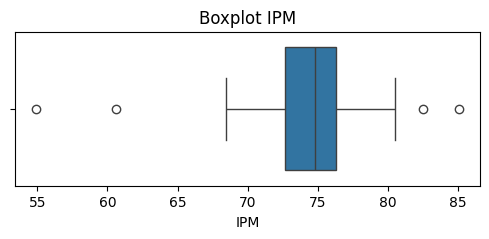

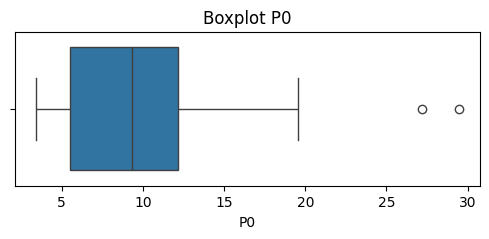

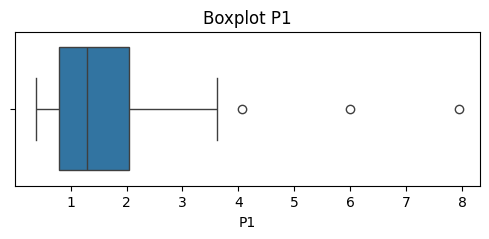

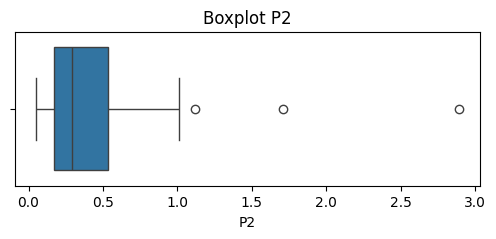

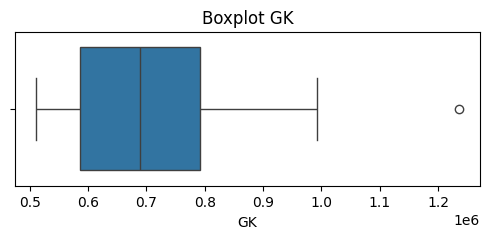

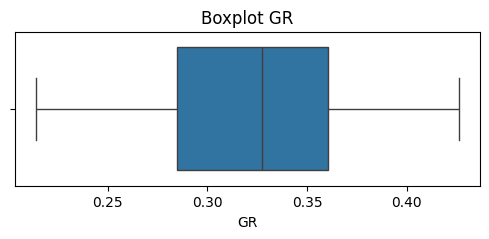

In [ ]:
# Visualisasi boxplot untuk melihat outlier
import matplotlib.pyplot as plt
import seaborn as sns

kolom_numerik = ['IPM', 'P0', 'P1', 'P2', 'GK', 'GR']
for col in kolom_numerik:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')
    plt.show()

**Kesimpulan:**

Dari boxplot terlihat bahwa:
* Hampir semua variabel memiliki outlier
* Variabel kemiskinan (P0, P1, P2) cenderung memiliki outlier di sisi kanan (nilai tinggi)
* Ini menunjukkan adanya perbedaan kondisi antar provinsi yang cukup besar

Dalam clustering seperti K-Means:
* outlier bisa mempengaruhi centroid
* sehingga biasanya dilakukan: normalisasi, pengecekan outlier
atau transformasi data bila diperlukan

##**Data Transformation**

###**Normalisasi Data**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Membaca file hasil penggabungan data
df = pd.read_csv('data_kemiskinan_lengkap.csv')

# Pilih kolom yang akan dinormalisasi (semua kecuali '38 Provinsi')
kolom_numerik = ['IPM', 'P0', 'P1', 'P2', 'GK', 'GR']

In [ ]:
# Normalisasi
# Inisialisasi scaler
scaler = MinMaxScaler()

# Buat dataframe baru yang sudah dinormalisasi
df_normalized = df.copy()
df_normalized[kolom_numerik] = scaler.fit_transform(df[kolom_numerik])

In [ ]:
# Simpan hasil normalisasi ke file CSV baru
df_normalized.to_csv('data_kemiskinan_normalisasi.csv', index=False)
print("✅ Data normalisasi berhasil disimpan!")

# Tampilkan beberapa baris pertama hasil normalisasi untuk pengecekan
print(df_normalized.head())

✅ Data normalisasi berhasil disimpan!
      38 Provinsi       IPM        P0        P1        P2        GK        GR
0            ACEH  0.707366  0.338071  0.222222  0.165493  0.281935  0.283019
1  SUMATERA UTARA  0.715328  0.146754  0.068783  0.049296  0.286238  0.325472
2  SUMATERA BARAT  0.741871  0.072609  0.063492  0.059859  0.366705  0.311321
3            RIAU  0.710020  0.110642  0.054233  0.035211  0.326439  0.424528
4           JAMBI  0.670869  0.133308  0.059524  0.035211  0.280204  0.363208


In [ ]:
import os

# Menentukan lokasi penyimpanan file di Google Drive
drive_path = '/content/drive/MyDrive/Tugas Akhir Dewi 2022-2026/'
output_filename = 'data_kemiskinan_normalisasi.csv'
full_output_path = os.path.join(drive_path, output_filename)

# Membuat folder jika folder belum tersedia
os.makedirs(drive_path, exist_ok=True)

# Menyimpan DataFrame ke Google Drive
df_normalized.to_csv(full_output_path, index=False)

print(f"✅ Data berhasil disimpan ke Google Drive di: {full_output_path}")

✅ Data berhasil disimpan ke Google Drive di: /content/drive/MyDrive/Tugas Akhir Dewi 2022-2026/data_kemiskinan_normalisasi.csv


###**Reduksi Dimensi Atau Principal Component Analysis (PCA)**

In [ ]:
import pickle
from sklearn.decomposition import PCA

# Tentukan lokasi penyimpanan file di Google Drive
drive_path = '/content/drive/MyDrive/Tugas Akhir Dewi 2022-2026/'
# Membuat folder jika belum ada
os.makedirs(drive_path, exist_ok=True)

In [ ]:
# Tahap PCA
# Ambil data normalisasi (tanpa kolom provinsi)
X = df_normalized[kolom_numerik]

In [ ]:
# Reduksi dari 6 dimensi menjadi 2 dimensi
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

In [ ]:
# Tambahkan hasil PCA ke dataframe untuk keperluan plot
df_normalized['PCA1'] = pca_result[:, 0]
df_normalized['PCA2'] = pca_result[:, 1]

In [ ]:
# Penyimpanan ke Google Drive
# A. Simpan hasil data yang sudah ternormalisasi + ada kolom PCA-nya
csv_output_path = os.path.join(drive_path, 'data_kemiskinan_tertransformasi.csv')
df_normalized.to_csv(csv_output_path, index=False)
print(f"✅ Data Normalisasi & PCA berhasil disimpan ke Drive di: {csv_output_path}")

# B. Simpan objek 'scaler' ke dalam bentuk .pkl untuk Streamlit
scaler_pkl_path = os.path.join(drive_path, 'scaler.pkl')
with open(scaler_pkl_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✅ Object Scaler (.pkl) berhasil disimpan di: {scaler_pkl_path}")

# C. Simpan objek 'pca' ke dalam bentuk .pkl untuk Streamlit (Kekurangan sebelumnya)
pca_pkl_path = os.path.join(drive_path, 'pca.pkl')
with open(pca_pkl_path, 'wb') as f:
    pickle.dump(pca, f)
print(f"✅ Object PCA (.pkl) berhasil disimpan di: {pca_pkl_path}")

✅ Data Normalisasi & PCA berhasil disimpan ke Drive di: /content/drive/MyDrive/Tugas Akhir Dewi 2022-2026/data_kemiskinan_tertransformasi.csv
✅ Object Scaler (.pkl) berhasil disimpan di: /content/drive/MyDrive/Tugas Akhir Dewi 2022-2026/scaler.pkl
✅ Object PCA (.pkl) berhasil disimpan di: /content/drive/MyDrive/Tugas Akhir Dewi 2022-2026/pca.pkl


In [ ]:
# Tampilkan data untuk pengecekan akhir
print("\n Hasil Data Siap Klastering")
print("=======================================")
print(df_normalized.head())


 Hasil Data Siap Klastering
      38 Provinsi       IPM        P0        P1        P2        GK        GR  \
0            ACEH  0.707366  0.338071  0.222222  0.165493  0.281935  0.283019   
1  SUMATERA UTARA  0.715328  0.146754  0.068783  0.049296  0.286238  0.325472   
2  SUMATERA BARAT  0.741871  0.072609  0.063492  0.059859  0.366705  0.311321   
3            RIAU  0.710020  0.110642  0.054233  0.035211  0.326439  0.424528   
4           JAMBI  0.670869  0.133308  0.059524  0.035211  0.280204  0.363208   

       PCA1      PCA2  
0 -0.003134 -0.197494  
1 -0.238408 -0.166647  
2 -0.276867 -0.218741  
3 -0.243916 -0.108993  
4 -0.235129 -0.141448  


#**Data Mining: Clustering (Pemodelan K-Means)**

###**Metode Elbow**

In [ ]:
# Ambil kolom numerik yang sudah dinormalisasi
kolom_numerik = ['IPM', 'P0', 'P1', 'P2', 'GK', 'GR']
X = df_normalized[kolom_numerik]

# Cek apakah sudah benar (nilai antara 0 dan 1)
print(X.head())

        IPM        P0        P1        P2        GK        GR
0  0.707366  0.338071  0.222222  0.165493  0.281935  0.283019
1  0.715328  0.146754  0.068783  0.049296  0.286238  0.325472
2  0.741871  0.072609  0.063492  0.059859  0.366705  0.311321
3  0.710020  0.110642  0.054233  0.035211  0.326439  0.424528
4  0.670869  0.133308  0.059524  0.035211  0.280204  0.363208


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Within-Cluster Sum of Squares atau WCSS adalah Jumlah Kuadrat Dalam Klaster
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

**Catatan:**

Dalam dunia Data Mining dan pengelompokan (clustering), WCSS adalah metrik yang digunakan untuk mengukur seberapa kompak atau seberapa rapat anggota-anggota di dalam sebuah klaster terhadap titik pusatnya (centroid).

Di dalam library scikit-learn Python, nilai WCSS ini disimpan secara otomatis di dalam atribut bernama inertia_ (makanya di kodemu tertulis kmeans.inertia_).

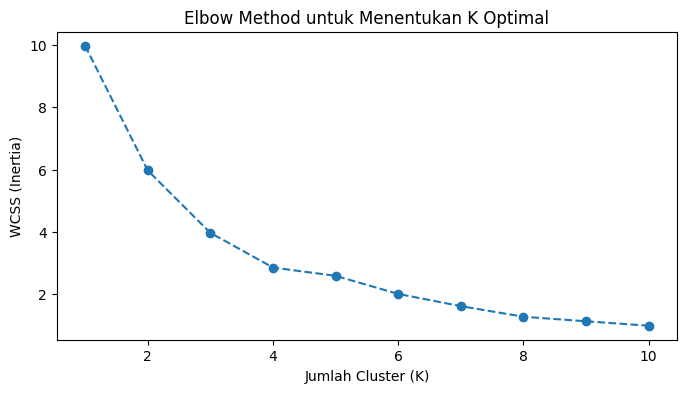

In [ ]:
# Plot Grafik Elbow
plt.figure(figsize=(8,4))
plt.plot(range(1,11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS (Inertia)')
plt.show()

**Analisis Metode Elbow Berdasarkan Grafik**

Jika kita melihat grafik garis WCSS:
* Penurunan nilai WCSS dari $K=1$ ke $K=2$ terlihat sangat tajam (drastis).
* Penurunan dari $K=2$ ke $K=3$ masih terlihat cukup jelas.
* Dari $K=3$ ke $K=4$, grafik mulai melandai dan membentuk tekukan siku (elbow) yang paling kentara. Setelah $K=3$ atau $K=4$, penurunan nilai WCSS sudah tidak terlalu signifikan lagi (stabil).
* Berdasarkan metode Elbow ini, jumlah klaster yang ideal berada di angka $K=3$ atau $K=4$.

##**Metode Silhouette Score**

In [ ]:
from sklearn.metrics import silhouette_score

for k in range (2,6):
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(X)
  score = silhouette_score(X, labels)
  print(f"Nilai Silhouette Score untuk K={k} adalah: {score:.4f}")

Nilai Silhouette Score untuk K=2 adalah: 0.6417
Nilai Silhouette Score untuk K=3 adalah: 0.3253
Nilai Silhouette Score untuk K=4 adalah: 0.3399
Nilai Silhouette Score untuk K=5 adalah: 0.3214


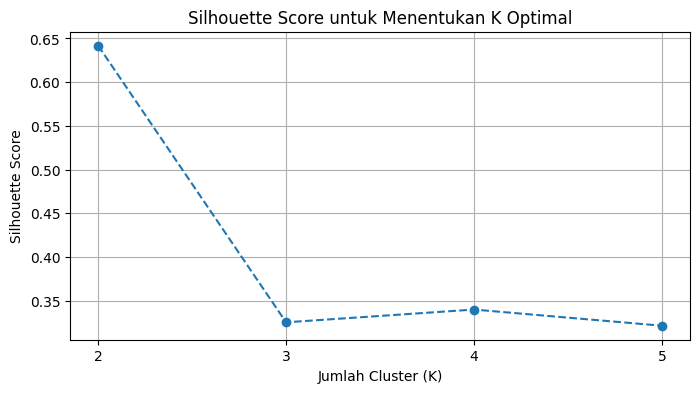

In [ ]:
# Plot Grafik Silhouette Score
k_values = [2, 3, 4, 5]
silhouette_scores = [0.6417, 0.3253, 0.3399, 0.3214]

plt.figure(figsize=(8,4))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score untuk Menentukan K Optimal')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()

**Analisis Metode Silhouette Score**

Nilai Silhouette Score mengukur seberapa dekat suatu data dengan klasternya sendiri dibandingkan dengan klaster lain (rentang nilainya $-1$ hingga $1$). Semakin tinggi nilainya, semakin baik pengelompokannya.
Dari data yang diberikan:
* $K=2$ memiliki nilai 0.6417 (Paling Tinggi / Struktur Klaster Kuat)
* $K=3$ memiliki nilai 0.3253
* $K=4$ memiliki nilai 0.3399 (Tertinggi kedua)
* $K=5$ memiliki nilai 0.3214

**Kesimpulan:**

Meskipun secara statistik metode Silhouette Score menunjukkan angka tertinggi pada K=2 (0.6417), pembagian menjadi hanya 2 kelompok umumnya kurang direkomendasikan untuk Profil Kemiskinan. Karena jika hanya dibagi menjadi 2 (misal: "Kemiskinan Tinggi" dan "Kemiskinan Rendah"), karakteristik spesifik wilayah seperti wilayah ketimpangan tinggi vs wilayah biaya hidup tinggi tidak akan terlihat.

Mengingat grafik Elbow mulai melandai pada sudut $K=3$ dan $K=4$, serta nilai Silhouette Score pada $K=4$ (0.3399) menunjukkan performa yang lebih baik dibanding $K=3$, maka diambil keputusan bahwa jumlah klaster terbaik yang digunakan dalam penelitian ini adalah $K=3$ atau $K=4$. Jumlah klaster ini dinilai paling optimal baik secara matematis maupun secara pemetaan karakteristik rekomendasi bantuan kebijakan.

# **Mengambil Keputusan Jumlah Klaster Terbaik K=3 atau K=4**

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans

# 1. Pastikan kamu menggunakan data asli (df) dan data normalisasi (df_normalized) dari tahap sebelumnya
# X adalah data fitur numerik yang sudah dinormalisasi
X = df_normalized[kolom_numerik]

print("====================================================")
# OPSI 1: EKSPERIMEN MENGGUNAKAN K = 3
print("📊 ANALISIS PROFILING UNTUK K = 3")
print("====================================================")

# Jalankan K-Means dengan 3 Klaster
kmeans_3 = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['Klaster_K3'] = kmeans_3.fit_predict(X)

# Hitung rata-rata variabel data asli berdasarkan Klaster K3
rata_rata_k3 = df.groupby('Klaster_K3')[kolom_numerik].mean()

# Hitung jumlah provinsi di setiap klaster
jumlah_provinsi_k3 = df['Klaster_K3'].value_counts().sort_index()
rata_rata_k3.insert(0, 'Jumlah Provinsi', jumlah_provinsi_k3)

# Tampilkan hasil rata-rata K=3
print(rata_rata_k3.round(3))


print("\n====================================================")
# OPSI 2: EKSPERIMEN MENGGUNAKAN K = 4
print("📊 ANALISIS PROFILING UNTUK K = 4")
print("====================================================")

# Jalankan K-Means dengan 4 Klaster
kmeans_4 = KMeans(n_clusters=4, init='k-means++', random_state=42)
df['Klaster_K4'] = kmeans_4.fit_predict(X)

# Hitung rata-rata variabel data asli berdasarkan Klaster K4
rata_rata_k4 = df.groupby('Klaster_K4')[kolom_numerik].mean()

# Hitung jumlah provinsi di setiap klaster
jumlah_provinsi_k4 = df['Klaster_K4'].value_counts().sort_index()
rata_rata_k4.insert(0, 'Jumlah Provinsi', jumlah_provinsi_k4)

# Tampilkan hasil rata-rata K=4
print(rata_rata_k4.round(3))

📊 ANALISIS PROFILING UNTUK K = 3
            Jumlah Provinsi     IPM      P0     P1     P2           GK     GR
Klaster_K3                                                                   
0                        18  74.885  11.431  1.938  0.478   648365.222  0.370
1                         2  57.775  28.330  6.965  2.300  1054585.500  0.344
2                        18  75.441   7.102  1.047  0.254   737281.556  0.285

📊 ANALISIS PROFILING UNTUK K = 4
            Jumlah Provinsi     IPM      P0     P1     P2           GK     GR
Klaster_K4                                                                   
0                        14  76.725   8.394  1.352  0.313   621588.286  0.364
1                         2  57.775  28.330  6.965  2.300  1054585.500  0.344
2                        16  75.280   6.822  0.946  0.217   739438.875  0.283
3                         6  71.207  17.818  3.278  0.890   734730.667  0.360


**Keputusan Jumlah Klaster Terbaik yaitu K=3**

Karena sebaran data sangat seimbang, data terbagi merata menjadi dua kelompok besar berisi masing-masing 18 provinsi (Klaster 0 dan Klaster 2), serta 2 provinsi ekstrem di Klaster 1. Ini pola pengelompokan yang sangat bagus karena tidak ada satu kelompok mayoritas tunggal yang terlalu mendominasi.


### **Rekomendasi Kebijakan Berdasarkan Hasil Clustering**

| Cluster | Profil Karakteristik | Rekomendasi Intervensi Kebijakan |
| :--- | :--- | :--- |
| **Cluster 0 (18 provinsi)** | **Profil Kemiskinan Menengah dengan Ketimpangan Tinggi** (Gini Ratio tertinggi) | **Pemberdayaan Ekonomi & Pemerataan:** Memerlukan program akses modal usaha bagi UMKM, pelatihan kerja, perluasan lapangan kerja padat karya, serta regulasi pemerataan upah untuk menekan angka Gini Ratio (ketimpangan). |
| **Cluster 1 (2 Provinsi)** | **Profil Kemiskinan Ekstrem & Biaya Hidup Sangat Tinggi** (P0, P1, P2, dan GK tertinggi, serta IPM terendah) | **Bantuan Pangan & Infrastruktur Dasar:** Memerlukan bantuan sosial mendesak (BLT, PKH, Sembako), pemenuhan akses fasilitas kesehatan dan pendidikan dasar, subsidi harga pangan untuk menekankan beban biaya hidup tinggi. |
| **Cluster 2 (18 Provinsi)** | **Profil Wilayah Sejahtera (Kemiskinan & Ketimpangan)** (IPM tertinggi, P0 terendah, serta GK terendah dan aman) | **Stimulus Ekonomi & Stabilitas Harga:** Memerlukan bantuan modal bagi pelaku usaha mikro (UMKM), operasi pasar untuk menjaga stabilitas harga, serta pemeliharaan tren positif pertumbuhan ekonomi lokal. |

# **Menjalankan Algoritma K-Means dan Menyimpan Model**

In [ ]:
# ==========================================
# FINAL MODEL K-MEANS UNTUK STREAMLIT
# ==========================================
import os
import pickle
from sklearn.cluster import KMeans

# Fitur yang digunakan model
kolom_numerik = ['IPM', 'P0', 'P1', 'P2', 'GK', 'GR']

# Data training
X = df_normalized[kolom_numerik]

# Model final
K_terbaik = 3

kmeans_final = KMeans(
    n_clusters=K_terbaik,
    init='k-means++',
    random_state=42,
    n_init=10
)

# FIT MODEL
kmeans_final.fit(X)

# Simpan label cluster
df['Klaster'] = kmeans_final.labels_
df_normalized['Klaster'] = kmeans_final.labels_

# ==========================================
# SIMPAN DATA FINAL UNTUK DASHBOARD
# ==========================================
final_csv_path = os.path.join(
    drive_path,
    'data_final_klaster.csv'
)

df_normalized.to_csv(
    final_csv_path,
    index=False
)

print(
    f"✅ Data final klaster berhasil disimpan ke Drive: "
    f"{final_csv_path}"
)

# ==========================================
# SIMPAN MODEL K-MEANS (.PKL)
# ==========================================
kmeans_pkl_path = os.path.join(
    drive_path,
    'kmeans_model.pkl'
)

with open(kmeans_pkl_path, 'wb') as f:
    pickle.dump(kmeans_final, f)

print(
    f"✅ Model K-Means berhasil disimpan ke Drive: "
    f"{kmeans_pkl_path}"
)

✅ Data final klaster berhasil disimpan ke Drive: /content/drive/MyDrive/Tugas Akhir Dewi 2022-2026/data_final_klaster.csv
✅ Model K-Means berhasil disimpan ke Drive: /content/drive/MyDrive/Tugas Akhir Dewi 2022-2026/kmeans_model.pkl


In [ ]:
# ==========================================
# VERIFIKASI MODEL
# ==========================================
print("\n===VERIFIKASI MODEL===")
print("Jumlah cluster :", kmeans_final.n_clusters)
print("Jumlah fitur   :", kmeans_final.n_features_in_)
print("Model fitted   :", hasattr(kmeans_final, 'cluster_centers_'))

print("\nCentroid:")
print(kmeans_final.cluster_centers_)

print("\nJumlah data tiap cluster:")
print(df_normalized['Klaster'].value_counts().sort_index())


===VERIFIKASI MODEL===
Jumlah cluster : 3
Jumlah fitur   : 6
Model fitted   : True

Centroid:
[[0.66274054 0.3077432  0.20605526 0.1508216  0.18981731 0.735587  ]
 [0.0950564  0.95697272 0.87103175 0.79225352 0.75052175 0.61084906]
 [0.68119148 0.14143936 0.08825691 0.07198748 0.31254821 0.33621593]]

Jumlah data tiap cluster:
Klaster
0    18
1     2
2    18
Name: count, dtype: int64


# **Melakukan Profiling / Interpretasi Karakteristik Klaster Menggunakan Data Asli (sebelum normalisasi)**


In [ ]:
import os
import pandas as pd
from sklearn.cluster import KMeans

# Pastikan folder Drive kamu sudah siap
drive_path = '/content/drive/MyDrive/Tugas Akhir Dewi 2022-2026/'

# Ambil data asli dan data numerik yang sudah dinormalisasi dari tahap sebelumnya
# df = Data asli (belum normalisasi)
# X = df_normalized[kolom_numerik] (sudah normalisasi)

# Jalankan K-Means Final dengan K = 3 sesuai keputusan
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42)

# Berikan label klaster ke dataframe DATA ASLI (df)
# fit_predict dilakukan pada data normalisasi (X), tapi hasilnya ditempel ke data asli (df)
df['Klaster'] = kmeans_final.fit_predict(X)

In [ ]:
# ==========================================
# PROSES PROFILING (MENGGUNAKAN DATA ASLI)
# ==========================================

# Hitung nilai rata-rata (mean) dari data asli berdasarkan Kelompok Klaster
tabel_profiling = df.groupby('Klaster')[kolom_numerik].mean()

# Hitung jumlah provinsi yang masuk ke masing-masing klaster
jumlah_provinsi = df['Klaster'].value_counts().sort_index()

# Sisipkan kolom 'Jumlah Provinsi' di bagian paling depan tabel agar informatif
tabel_profiling.insert(0, 'Jumlah Provinsi', jumlah_provinsi)

In [ ]:
# Tampilkan hasil profiling ke layar (dibulatkan 3 angka di belakang koma agar rapi)
print("=====================================================================")
print("TABEL PROFILING KARAKTERISTIK KLASTER (DATA ASLI)")
print("=====================================================================")
print(tabel_profiling.round(3))
print("=====================================================================\n")

TABEL PROFILING KARAKTERISTIK KLASTER (DATA ASLI)
         Jumlah Provinsi     IPM      P0     P1     P2           GK     GR
Klaster                                                                   
0                     18  74.885  11.431  1.938  0.478   648365.222  0.370
1                      2  57.775  28.330  6.965  2.300  1054585.500  0.344
2                     18  75.441   7.102  1.047  0.254   737281.556  0.285



In [ ]:
# Tampilkan daftar nama provinsi untuk setiap klaster (untuk mempermudah analisis Bab 4)
print("DAFTAR PROVINSI PER KLASTER:")
for i in range(3):
    provinsi_klaster = df[df['Klaster'] == i]['38 Provinsi'].tolist()
    print(f"\nKlaster {i} ({len(provinsi_klaster)} Provinsi):")
    print(", ".join(provinsi_klaster))

DAFTAR PROVINSI PER KLASTER:

Klaster 0 (18 Provinsi):
BENGKULU, KEPULAUAN RIAU, DKI JAKARTA, JAWA BARAT, JAWA TENGAH, DI YOGYAKARTA, JAWA TIMUR, NUSA TENGGARA BARAT, NUSA TENGGARA TIMUR, SULAWESI UTARA, SULAWESI SELATAN, SULAWESI TENGGARA, GORONTALO, SULAWESI BARAT, PAPUA BARAT, PAPUA BARAT DAYA, PAPUA, PAPUA SELATAN

Klaster 1 (2 Provinsi):
PAPUA TENGAH, PAPUA PEGUNUNGAN

Klaster 2 (18 Provinsi):
ACEH, SUMATERA UTARA, SUMATERA BARAT, RIAU, JAMBI, SUMATERA SELATAN, LAMPUNG, KEPULAUAN BANGKA BELITUNG, BANTEN, BALI, KALIMANTAN BARAT, KALIMANTAN TENGAH, KALIMANTAN SELATAN, KALIMANTAN TIMUR, KALIMANTAN UTARA, SULAWESI TENGAH, MALUKU, MALUKU UTARA


In [ ]:
# Simpan data asli yang sudah ditempel label klaster ini ke file CSV baru di Drive
# File inilah yang nantinya dibaca oleh tabel utama di Streamlit
output_profil_path = os.path.join(drive_path, 'data_final_dengan_klaster.csv')
df.to_csv(output_profil_path, index=False)
print(f"\n✅ Data hasil profiling berhasil disimpan di: {output_profil_path}")


✅ Data hasil profiling berhasil disimpan di: /content/drive/MyDrive/Tugas Akhir Dewi 2022-2026/data_final_dengan_klaster.csv
